<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
《<a href="http://mng.bz/orYv">Build a Large Language Model From Scratch</a>》一书的补充代码，作者 <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>代码仓库：<a href="https://github.com/rasbt/LLMs-from-scratch">https://github.com/rasbt/LLMs-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="http://mng.bz/orYv"><img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

# FLOPS 分析

- FLOPs（Floating Point Operations Per Second，每秒浮点运算次数）通过统计执行的浮点运算数量来衡量神经网络模型的计算复杂度
- FLOPs 越高，通常表示计算和能耗越密集

In [1]:
# pip install -r requirements-extra.txt

In [2]:
import torch
from importlib.metadata import version

pkgs = [
    "thop",
    "torch",
]
for p in pkgs:
    print(f"{p} version: {version(p)}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

thop version: 0.1.1-2209072238
torch version: 2.7.1+cu118


device(type='cuda')

&nbsp;
# 固定 batch size 的简单基准测试

- 仅前向传播

In [ ]:
import torch
#thop 是一个用于计算 PyTorch 模型的 FLOPs（浮点运算次数）和参数数量的库。
# 它可以帮助我们分析模型的计算复杂度和资源需求。
from thop import profile
#profile 函数用于计算给定模型的 FLOPs 和参数数量。它接受一个模型和输入张量，
# 并返回模型的 FLOPs 和参数数量。

# For installation instructions, see:
# https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# 使用colab时，将llms_from_scratch.ch04替换成gpt
from llms_from_scratch.ch04 import GPTModel


BASE_CONFIG = {
    "vocab_size": 50257,     # 词表大小
    "context_length": 1024,  # 上下文长度
    "drop_rate": 0.0,        # Dropout 比率
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 2
input_tensor = torch.randint(0, 50257, (batch_size, 1024)).to(device)

for size in model_configs:
    BASE_CONFIG.update(model_configs[size])
    #把模型参数转成 bfloat16 精度, 以减少内存占用和计算时间
    model = GPTModel(BASE_CONFIG).bfloat16()
    model.to(device)

    # MACS = multiply-accumulate operations一次乘法加一次加法
    # MACS are typically counted as two FLOPS (one multiply and one accumulate)
    # macs   = 乘加运算次数,params = 参数量
    # verbose=False：在计算 FLOPs 和参数数量时，不输出详细的计算过程和结果。
    macs, params = profile(model, inputs=(input_tensor,), verbose=False)
    flops = 2*macs
    print(f"{size:18}: {flops:.1e} FLOPS")

    #del 因为模型很大，测完一个模型后要释放显存，否则下一个模型可能 OOM
    del model
    #empty_cache() 是 PyTorch 中的一个方法，用于清空 CUDA 缓存。
    torch.cuda.empty_cache()

gpt-small (124M)  : 5.1e+11 FLOPS
gpt-medium (355M) : 1.4e+12 FLOPS
gpt-large (774M)  : 3.2e+12 FLOPS
gpt-xl (1558M)    : 6.4e+12 FLOPS


&nbsp;
# 自动寻找 batch size 的简单基准测试

- 仅前向传播

In [9]:
for size in model_configs:
    print(f"\nProcessing {size}")
    config = BASE_CONFIG.copy()
    config.update(model_configs[size])

    min_batch_size = 1
    max_batch_size = None
    max_possible_batch_size = 4096

    while min_batch_size <= max_possible_batch_size:
        batch_size = (min_batch_size + max_possible_batch_size) // 2
        try:
            input_tensor = torch.randint(
                0, config["vocab_size"],
                (batch_size, config["context_length"]),
                device=device
            )

            model = GPTModel(config).bfloat16().to(device)

            # MACS = multiply-accumulate operations
            # MACS are typically counted as two FLOPS (one multiply and one accumulate)
            macs, params = profile(model, inputs=(input_tensor,), verbose=False)
            flops = 2 * macs
            print(f"  Batch size {batch_size}: {flops:.1e} FLOPS")

            # If successful, try a larger batch size
            min_batch_size = batch_size + 1
            max_batch_size = batch_size

            # Clean up
            del model, input_tensor
            torch.cuda.empty_cache()

        #e 是 RuntimeError 的实例，表示在运行时发生了错误。
        except RuntimeError as e:
            if "out of memory" in str(e):
                # Try smaller batch size
                max_possible_batch_size = batch_size - 1

                # Clean up
                try:
                    del model, input_tensor
                    torch.cuda.empty_cache()
                except NameError:
                    pass
            else:
# raise e 是 Python 中的语句，用于引发一个异常。在这里，如果捕获到的 RuntimeError 不是由于内存不足引起的，
# 那么就会重新引发这个异常，以便在其他地方处理。
                raise e


Processing gpt-small (124M)

Processing gpt-medium (355M)

Processing gpt-large (774M)

Processing gpt-xl (1558M)


在colab上用T4(16G)跑出的结果：

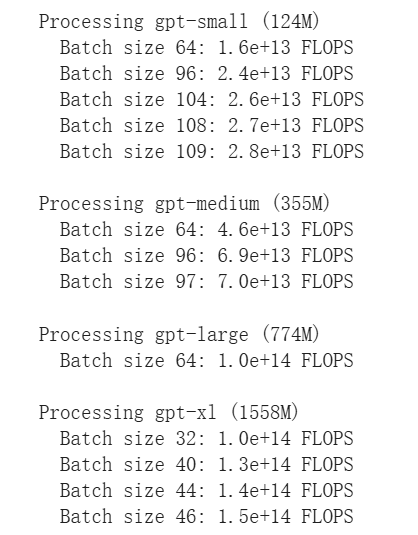

&nbsp;
# 自动寻找 batch size 并计算 Model FLOP Utilization（MFU）的基准测试

- Model FLOPs Utilization（MFU）的解释来自 [PaLM 论文](https://arxiv.org/abs/2204.02311)

> We propose a new metric for efficiency that is implementation-independent and permits a cleaner comparison of system efficiency, called model FLOPs utilization (MFU). This is the ratio of the observed throughput (tokens-per-second) relative to the theoretical maximum throughput of a system operating at peak FLOPs. Crucially, the “theoretical maximum” throughput only accounts for the required operations to compute the forward+backward passes, and not rematerialization.
>我们提出了一个新的效率度量方法，它与实现无关，并且可以更清晰地比较系统效率，称为模型 FLOPs 利用率（MFU）。它是观察到的吞吐量（每秒处理的 token 数）与系统在峰值 FLOPs 下理论最大吞吐量的比值。关键是，“理论最大”吞吐量只计算前向+反向计算所需的操作，不包括重新物化。

$$\text{MFU} = \frac{\text{Observed Tokens per Second}}{\text{Theoretical Max Tokens per Second}}$$

其中

$$\text{Theoretical Max Tokens per Second} = \frac{\text{Max FLOPs per Second}}{\text{Total FLOPs per Token}}$$

并且

$$\text{Tokens per Second} = \frac{\text{Batch Size} \times \text{Sequence Length}}{\text{Total Time}}$$

- 前向传播和反向传播

In [5]:
# Theoretical max flops per second provided by the GPU manufacturer

flops_per_second = {
    # https://www.techpowerup.com/gpu-specs/h100-pcie-80-gb.c3899
    "H100": {
        torch.float32: 51.22e12,  # 51.22 TFLOPs for FP32 on NVIDIA H100
        torch.float16: 204.9e12,  # 204.9 TFLOPs for FP16 on NVIDIA H100
        torch.bfloat16: 204.9e12
    },
    # https://www.techpowerup.com/gpu-specs/l4.c4091
    "L4": {
        torch.float32: 30.29e12,  # 30.29 TFLOPs for FP32 on NVIDIA L4
        torch.float16: 30.29e12,  # 30.29 TFLOPs for FP16 on NVIDIA L4
        torch.bfloat16: 30.29e12
    },
    # https://www.techpowerup.com/gpu-specs/tesla-t4.c3316
    "T4": {
        torch.float32: 8.1e12,  # 8.1 TFLOPs for FP32 on NVIDIA T4
        torch.float16: 65.13e12,  # 65.13 TFLOPs for FP16 on NVIDIA T4
        torch.bfloat16: 65.13e12
    },
    # https://www.techpowerup.com/gpu-specs/a10g.c3798
    "A10G": {
        torch.float32: 31.52e12,  # 31.52 TFLOPs for FP32 on NVIDIA A10G
        torch.float16: 31.52e12,  # 31.52 TFLOPs for FP16 on NVIDIA A10G
        torch.bfloat16: 31.52e12
    },
    # https://www.techpowerup.com/gpu-specs/a100-pcie-40-gb.c3623
    "A100": {
        torch.float32: 19.49e12,  # 19.49 TFLOPs for FP32 on NVIDIA A100
        torch.float16: 77.97e12,  # 77.97 TFLOPs for FP16 on NVIDIA A100
        torch.bfloat16: 77.97e12
    },
    # https://www.techpowerup.com/gpu-specs/geforce-rtx-3080.c3621
    "RTX_3080": {
        torch.float32: 29.77e12,  # 29.77 TFLOPs for FP32 on NVIDIA RTX 3080
        torch.float16: 29.77e12,  # 29.77 TFLOPs for FP16 on NVIDIA RTX 3080
        torch.bfloat16: 29.77e12
    },
    # https://www.techpowerup.com/gpu-specs/geforce-rtx-3090.c3622
    "RTX_3090": {
        torch.float32: 35.58e12,  # 35.58 TFLOPs for FP32 on NVIDIA RTX 3090
        torch.float16: 35.58e12,  # 35.58 TFLOPs for FP16 on NVIDIA RTX 3090
        torch.bfloat16: 35.58e12
    }
}


In [ ]:
import time

def get_gpu_model(flops_per_second_dict):
    #get_device_name(0) 返回当前使用的 GPU 设备的名称，例如 "NVIDIA GeForce RTX 3080"。
    device_name = torch.cuda.get_device_name(0)
    for model in flops_per_second_dict.keys():
        if model in device_name:
            return model
    return "Unknown"  # Default if no matching model is found


gpu_model = get_gpu_model(flops_per_second)
print("GPU Model:", gpu_model)

if gpu_model != "Unknown":

    for size in model_configs:
        print(f"\nProcessing {size}")
        config = BASE_CONFIG.copy()
        config.update(model_configs[size])

        min_batch_size = 1
        max_batch_size = None
        max_possible_batch_size = 4096

        while min_batch_size <= max_possible_batch_size:
            batch_size = (min_batch_size + max_possible_batch_size) // 2
            try:
                input_tensor = torch.randint(
                    0, config["vocab_size"],
                    (batch_size, config["context_length"]),
                    device=device
                )

                model = GPTModel(config).bfloat16().to(device)
                #训练模式下:
                #    Dropout 会启用
                #    LayerNorm 等层正常训练行为
                #    可以执行反向传播
                model.train()

                # Start timing
                #synchronize() 方法用于确保在计时开始之前，所有先前的 CUDA 操作都已完成。这对于准确测量 GPU 上的操作时间非常重要。
                torch.cuda.synchronize()
                start_time = time.time()

                # Forward & backward pass
                output = model(input_tensor)
                loss = output.sum()  # Compute a dummy loss
                loss.backward()

                # End timing
                torch.cuda.synchronize()
                end_time = time.time()

                total_time_seconds = end_time - start_time

                # Calculate FLOPs for forward pass
                macs, params = profile(model, inputs=(input_tensor,), verbose=False)
                flops_forward = 2 * macs  # Assuming one MAC equals two FLOPs

                # Estimate FLOPs for backward pass (typically 2x forward FLOPs)
                flops_backward = 2 * flops_forward

                # Total FLOPs for forward + backward passes
                total_flops = flops_forward + flops_backward  # Or total_flops = flops_forward * 3


                data_type = next(model.parameters()).dtype
                max_flops_per_second = flops_per_second[gpu_model].get(data_type, 0)

                # Compute tokens per second
                tokens_processed = batch_size * config["context_length"]
                tokens_per_second = tokens_processed / total_time_seconds

                # Compute FLOPs per token
                flops_per_token = total_flops / tokens_processed

                # Compute theoretical max tokens per second
                if flops_per_token > 0:
                    theoretical_max_tokens_per_second = max_flops_per_second / flops_per_token
                else:
                    theoretical_max_tokens_per_second = 0  # Avoid division by zero

                # Compute MFU
                if theoretical_max_tokens_per_second > 0:
                    mfu = tokens_per_second / theoretical_max_tokens_per_second
                else:
                    mfu = 0  # Avoid division by zero

                print(f"  Batch size {batch_size}: Tokens/sec: {tokens_per_second:.2f}, MFU: {mfu:.4f}")

                # If successful, try a larger batch size
                min_batch_size = batch_size + 1
                max_batch_size = batch_size

                # Clean up
                del model, input_tensor, output, loss
                torch.cuda.empty_cache()

            except RuntimeError as e:
                #lower() 方法将字符串中的所有字符转换为小写字母。这是为了确保在检查错误消息时，不区分大小写。
                if "out of memory" in str(e).lower():
                    # Try smaller batch size
                    max_possible_batch_size = batch_size - 1

                    # Clean up
                    try:
                        del model, input_tensor
                        torch.cuda.empty_cache()
                    except NameError:
                        pass
                else:
                    raise e

else:
    print("Unknown GPU model. Please update the flops_per_second dictionary with your GPU information.")

GPU Model: A100

Processing gpt-small (124M)
  Batch size 16: Tokens/sec: 34248.82, MFU: 0.3256
  Batch size 24: Tokens/sec: 62568.34, MFU: 0.5948

Processing gpt-medium (355M)
  Batch size 4: Tokens/sec: 20159.93, MFU: 0.5483
  Batch size 6: Tokens/sec: 21717.66, MFU: 0.5907
  Batch size 7: Tokens/sec: 22536.25, MFU: 0.6130

Processing gpt-large (774M)
  Batch size 8: Tokens/sec: 12465.21, MFU: 0.7406

Processing gpt-xl (1558M)
  Batch size 4: Tokens/sec: 6779.92, MFU: 0.8113


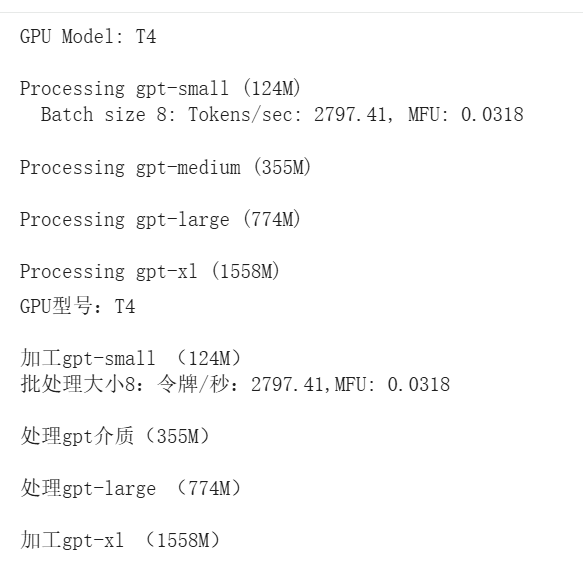

- 1.0 是最佳值（等于 100%）
- 注意，这里的 batch size 比前面更小，因为这里还会执行反向传播，内存开销更大